In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize
from scipy.signal import find_peaks

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [12]:
%matplotlib notebook

In [2]:
datapath = r"C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\data\slap2_cell_table.pkl"

In [3]:
data = pd.read_pickle(datapath)

In [48]:
sorted_data = data.sort_values('robust_snr').iloc[:20].reset_index()

<IPython.core.display.Javascript object>


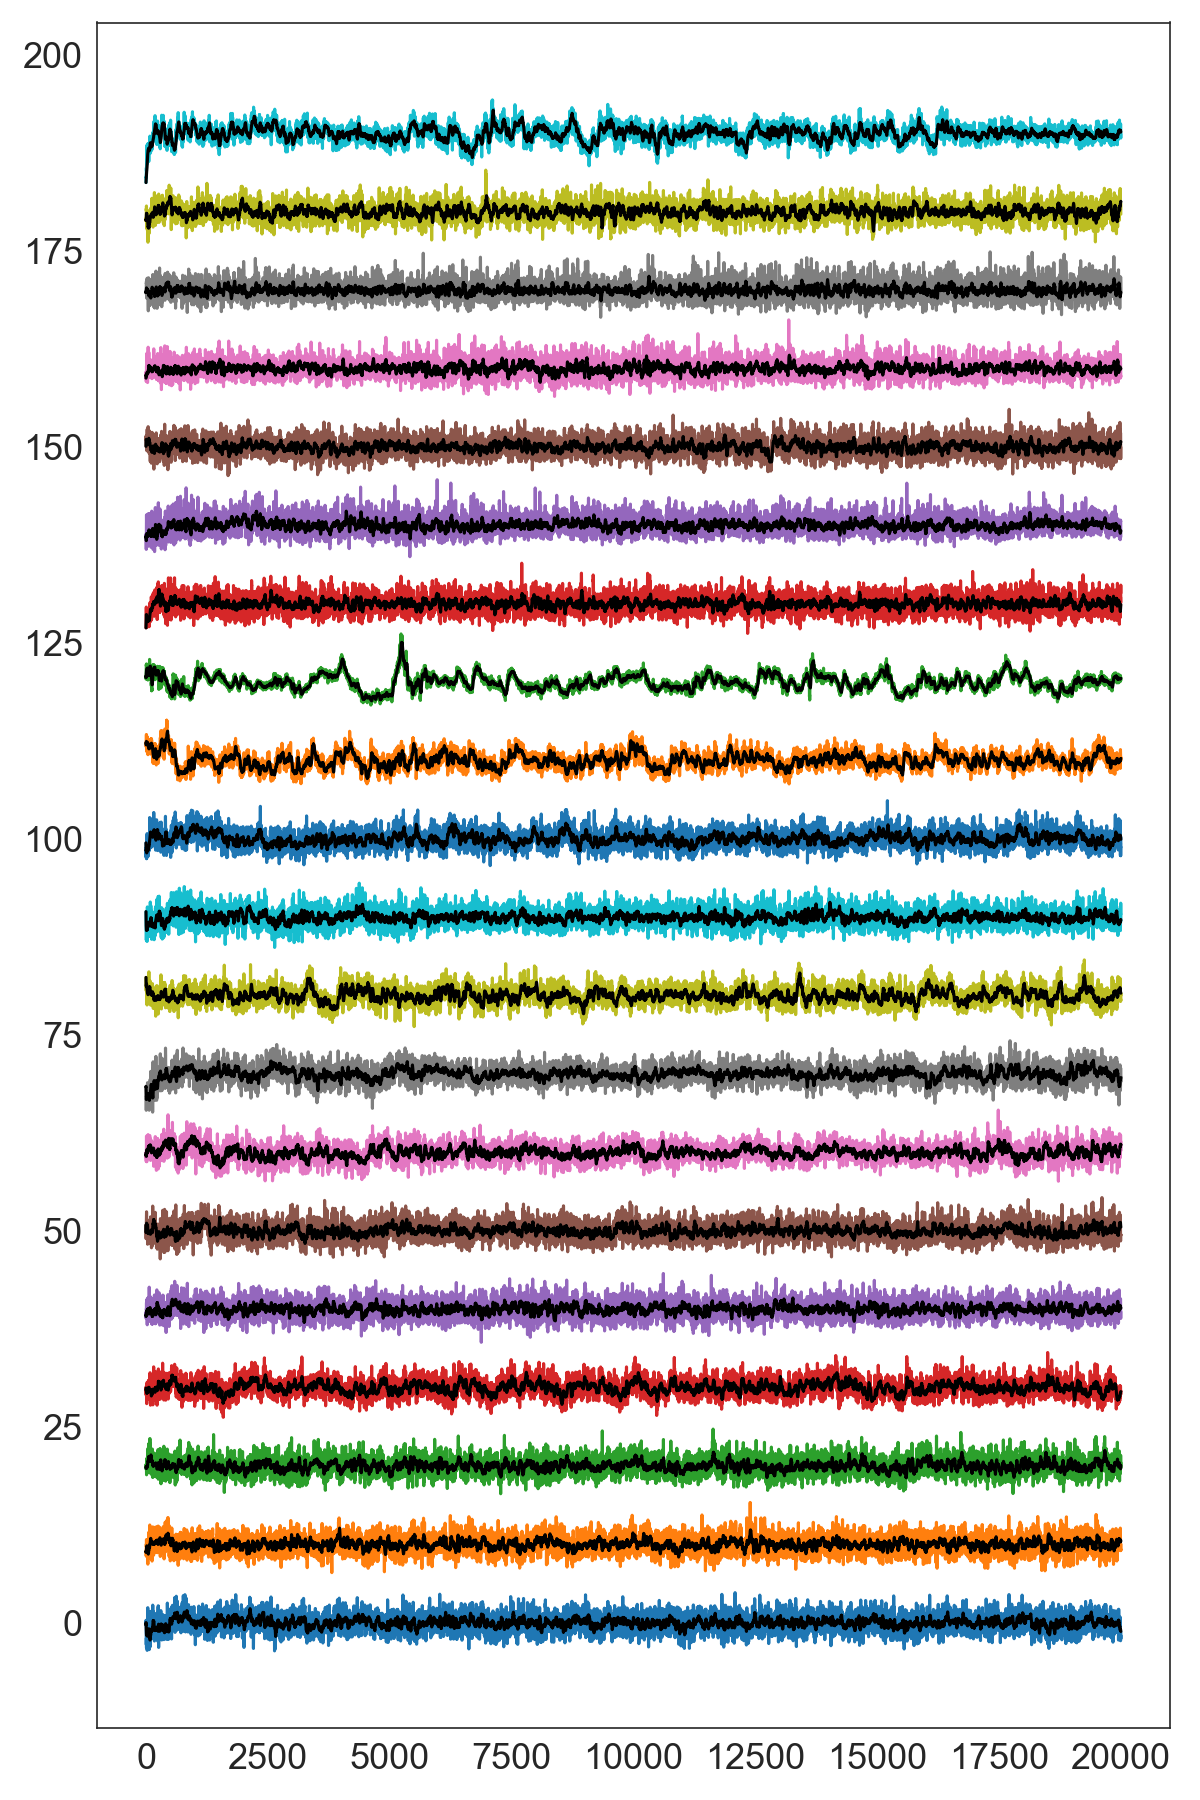

In [55]:
fig,ax=plt.subplots(figsize=(8,12))

offset = 10

for idx,row in sorted_data.iterrows():
    
    soma_roi = ((row['dff'][:20000])-np.mean(row['dff'][:20000]))/np.std(row['dff'][:20000])
    rolling = pd.DataFrame(soma_roi).rolling(25,min_periods=1).mean()

    ax.plot(soma_roi+idx*offset)
    ax.plot(rolling+idx*offset,color='k')
fig.tight_layout()

In [51]:
sorted_data

,index,subject_id,session_id,session_date,session_type,stimulus_block,z,roi_id,fov_id,dff,valid_roi,robust_noise,robust_signal,robust_snr
0,23,826033,826033_2026-02-21_09-23-34,2026-02-21T00:00:00,familiar,change_detection_passive,200.0,1,DMD2,"[-0.010998349381321644, 0.013628664990948482, ...",True,0.043313,0.061874,1.428526
1,46,838410,838410_2026-03-02_12-40-55,2026-03-02T00:00:00,familiar,change_detection_passive,25.0,3,DMD1,"[-0.03331979720806622, -0.02927381222050945, -...",True,0.042339,0.060614,1.431659
2,45,838410,838410_2026-03-02_12-40-55,2026-03-02T00:00:00,familiar,change_detection_passive,25.0,2,DMD1,"[-0.005422534290333586, -0.013630572636042995,...",True,0.051974,0.074424,1.431940
3,50,838410,838410_2026-03-02_12-40-55,2026-03-02T00:00:00,familiar,change_detection_passive,200.0,3,DMD2,"[-0.003556235048777173, -0.00656858109831435, ...",True,0.051522,0.073809,1.432566
4,56,826033,826033_2026-02-23_10-45-21,2026-02-23T00:00:00,familiar,change_detection_passive,200.0,3,DMD2,"[-0.03670060184067266, -0.01565665922393272, -...",True,0.041606,0.059681,1.434436
5,69,834788,834788_2026-03-05_08-11-16,2026-03-05T00:00:00,familiar,change_detection_passive,200.0,1,DMD2,"[0.0244347294189266, -0.010542207779730502, -0...",True,0.039820,0.057156,1.435367
6,51,838410,838410_2026-03-02_12-40-55,2026-03-02T00:00:00,familiar,change_detection_passive,200.0,4,DMD2,"[-0.0025256217396664995, -0.027421818513166125...",True,0.043718,0.062773,1.435859
7,61,826033,826033_2026-02-24_14-14-45,2026-02-24T00:00:00,familiar,change_detection_passive,200.0,0,DMD2,"[-0.029529693430060164, -0.02798941501446885, ...",True,0.021409,0.030783,1.437811
8,31,838410,838410_2026-03-04_12-54-47,2026-03-04T00:00:00,familiar,change_detection_passive,200.0,0,DMD2,"[0.18094056788042853, 0.10942173432053989, 0.0...",True,0.066776,0.096310,1.442279
9,22,826033,826033_2026-02-21_09-23-34,2026-02-21T00:00:00,familiar,change_detection_passive,200.0,0,DMD2,"[0.03230248019473183, -0.052713168752599106, -...",True,0.046792,0.067510,1.442753
